# AHP Priority Ranking - Sample Development Pipeline

## Decision Support Stage

This notebook documents the AHP calculation pipeline for SentiRank. Phase 10C uses sample development judgements only to verify that the backend AHP service, CSV templates, exported metrics, and figures work end to end.

**Important:** outputs in this notebook are marked `sample_development_only` and `not_final_expert_judgement`. They are not final AHP weights and must not be used as thesis ranking results.

## AHP Role in SentiRank

AHP converts expert pairwise judgements into priority weights for the five selected improvement criteria. The criteria come from the selected SVM `merged_5class` aspect taxonomy, but final weighting still requires real expert judgement.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "ml-service").exists()
            and (candidate / "datasets").exists()
            and (candidate / "docs").exists()
        ):
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root()
ML_SERVICE_DIR = PROJECT_ROOT / "ml-service"
TEMPLATE_DIR = PROJECT_ROOT / "docs" / "templates" / "ahp"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ML_SERVICE_DIR:", ML_SERVICE_DIR)

PROJECT_ROOT: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank
ML_SERVICE_DIR: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service


In [2]:
def load_json(path: Path):
    if not path.exists():
        print(f"Missing JSON: {path}")
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def load_csv(path: Path):
    if not path.exists():
        print(f"Missing CSV: {path}")
        return None
    return pd.read_csv(path)


def display_image(path: Path) -> None:
    if not path.exists():
        print(f"Missing figure: {path}")
        return
    display(Image(filename=str(path)))


def run_ml_script(script_name: str) -> None:
    command = [sys.executable, "scripts/" + script_name]
    result = subprocess.run(
        command,
        cwd=ML_SERVICE_DIR,
        text=True,
        capture_output=True,
        check=False,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Script failed: {script_name}")

## Final Candidate Criteria

The `General` fallback label is excluded. These criteria remain expert-validation candidates until real respondents provide pairwise comparisons.

In [3]:
criteria_payload = load_json(TEMPLATE_DIR / "final_criteria_for_ahp.json")
if criteria_payload:
    criteria_df = pd.DataFrame(criteria_payload["criteria"])
    display(criteria_df[["criterion_id", "criterion_name", "description", "source_labels", "expert_validation_required"]])

,criterion_id,criterion_name,description,source_labels,expert_validation_required
0,C1,"Features, Content & Audio Experience",Issues or improvement priorities related to mu...,"[Features & Content, Audio Quality]",True
1,C2,App Reliability & Usability,Issues or improvement priorities related to ap...,"[Performance & Stability, UI/UX]",True
2,C3,Ads Experience,Issues or improvement priorities related to ad...,[Ads Experience],True
3,C4,Subscription & Pricing,Issues or improvement priorities related to pr...,[Subscription & Pricing],True
4,C5,Account/Login,Issues or improvement priorities related to ac...,[Account/Login],True


## Sample AHP Input

The sample input contains exactly 10 pairwise comparisons for 5 criteria. It is deliberately consistent for pipeline validation and is not a substitute for expert judgement.

In [4]:
ahp_sample_input = TEMPLATE_DIR / "sample_development" / "ahp_pairwise_sample_development.csv"
ahp_input_df = load_csv(ahp_sample_input)
if ahp_input_df is not None:
    display(ahp_input_df)
    print("Pairwise comparisons:", len(ahp_input_df))

,respondent_id,respondent_role,comparison_id,criterion_a,criterion_b,preferred_criterion,intensity_saaty,ahp_value_a_over_b,justification,run_label,not_final_expert_judgement
0,SAMPLE_DEV,Development sample,P01,"Features, Content & Audio Experience",App Reliability & Usability,criterion_b,3,0.333333,"Sample development only, not final expert judg...",sample_development_only,True
1,SAMPLE_DEV,Development sample,P02,"Features, Content & Audio Experience",Ads Experience,criterion_a,3,3.000000,"Sample development only, not final expert judg...",sample_development_only,True
2,SAMPLE_DEV,Development sample,P03,"Features, Content & Audio Experience",Subscription & Pricing,equal,1,1.000000,"Sample development only, not final expert judg...",sample_development_only,True
3,SAMPLE_DEV,Development sample,P04,"Features, Content & Audio Experience",Account/Login,criterion_a,3,3.000000,"Sample development only, not final expert judg...",sample_development_only,True
4,SAMPLE_DEV,Development sample,P05,App Reliability & Usability,Ads Experience,criterion_a,9,9.000000,"Sample development only, not final expert judg...",sample_development_only,True
5,SAMPLE_DEV,Development sample,P06,App Reliability & Usability,Subscription & Pricing,criterion_a,3,3.000000,"Sample development only, not final expert judg...",sample_development_only,True
6,SAMPLE_DEV,Development sample,P07,App Reliability & Usability,Account/Login,criterion_a,9,9.000000,"Sample development only, not final expert judg...",sample_development_only,True
7,SAMPLE_DEV,Development sample,P08,Ads Experience,Subscription & Pricing,criterion_b,3,0.333333,"Sample development only, not final expert judg...",sample_development_only,True
8,SAMPLE_DEV,Development sample,P09,Ads Experience,Account/Login,equal,1,1.000000,"Sample development only, not final expert judg...",sample_development_only,True
9,SAMPLE_DEV,Development sample,P10,Subscription & Pricing,Account/Login,criterion_a,3,3.000000,"Sample development only, not final expert judg...",sample_development_only,True


Pairwise comparisons: 10


## Run Sample AHP Calculation

This cell runs only the sample-development script. It writes to `datasets/outputs/eda/06_ahp/sample_development/` and does not create final `ahp_weights.csv` or ranking outputs.

In [5]:
run_ml_script("calculate_ahp_from_expert_judgement.py")

AHP sample weights written to: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\06_ahp\sample_development\ahp_weights_sample_development.json
AHP sample consistency ratio: 0.0000000000
AHP sample figure written to: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\docs\figures\06_ahp\sample_development\ahp_weights_sample_development.png



## Sample AHP Outputs

The outputs below are useful for checking the pipeline shape: weights, pairwise matrix, and consistency ratio.

In [6]:
AHP_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "06_ahp" / "sample_development"
AHP_FIGURE_DIR = PROJECT_ROOT / "docs" / "figures" / "06_ahp" / "sample_development"

weights_df = load_csv(AHP_OUTPUT_DIR / "ahp_weights_sample_development.csv")
if weights_df is not None:
    display(weights_df.sort_values("rank"))

consistency = load_json(AHP_OUTPUT_DIR / "ahp_consistency_sample_development.json")
if consistency:
    display(pd.DataFrame([consistency]))

matrix_df = load_csv(AHP_OUTPUT_DIR / "ahp_pairwise_matrix_sample_development.csv")
if matrix_df is not None:
    display(matrix_df)

,criterion_id,criterion_name,weight,rank,run_label,is_sample,not_final_expert_judgement
1,C2,App Reliability & Usability,0.529412,1,sample_development_only,True,True
0,C1,"Features, Content & Audio Experience",0.176471,2,sample_development_only,True,True
3,C4,Subscription & Pricing,0.176471,3,sample_development_only,True,True
2,C3,Ads Experience,0.058824,4,sample_development_only,True,True
4,C5,Account/Login,0.058824,5,sample_development_only,True,True


,run_label,is_sample,not_final_expert_judgement,lambda_max,consistency_index,consistency_ratio,consistency_threshold,is_consistent,warnings
0,sample_development_only,True,True,5.0,0.0,0.0,0.1,True,[]


,criterion_id,criterion_name,C1,C2,C3,C4,C5
0,C1,"Features, Content & Audio Experience",1.000000,0.333333,3.0,1.000000,3.0
1,C2,App Reliability & Usability,3.000000,1.000000,9.0,3.000000,9.0
2,C3,Ads Experience,0.333333,0.111111,1.0,0.333333,1.0
3,C4,Subscription & Pricing,1.000000,0.333333,3.0,1.000000,3.0
4,C5,Account/Login,0.333333,0.111111,1.0,0.333333,1.0


## Sample AHP Weight Figure

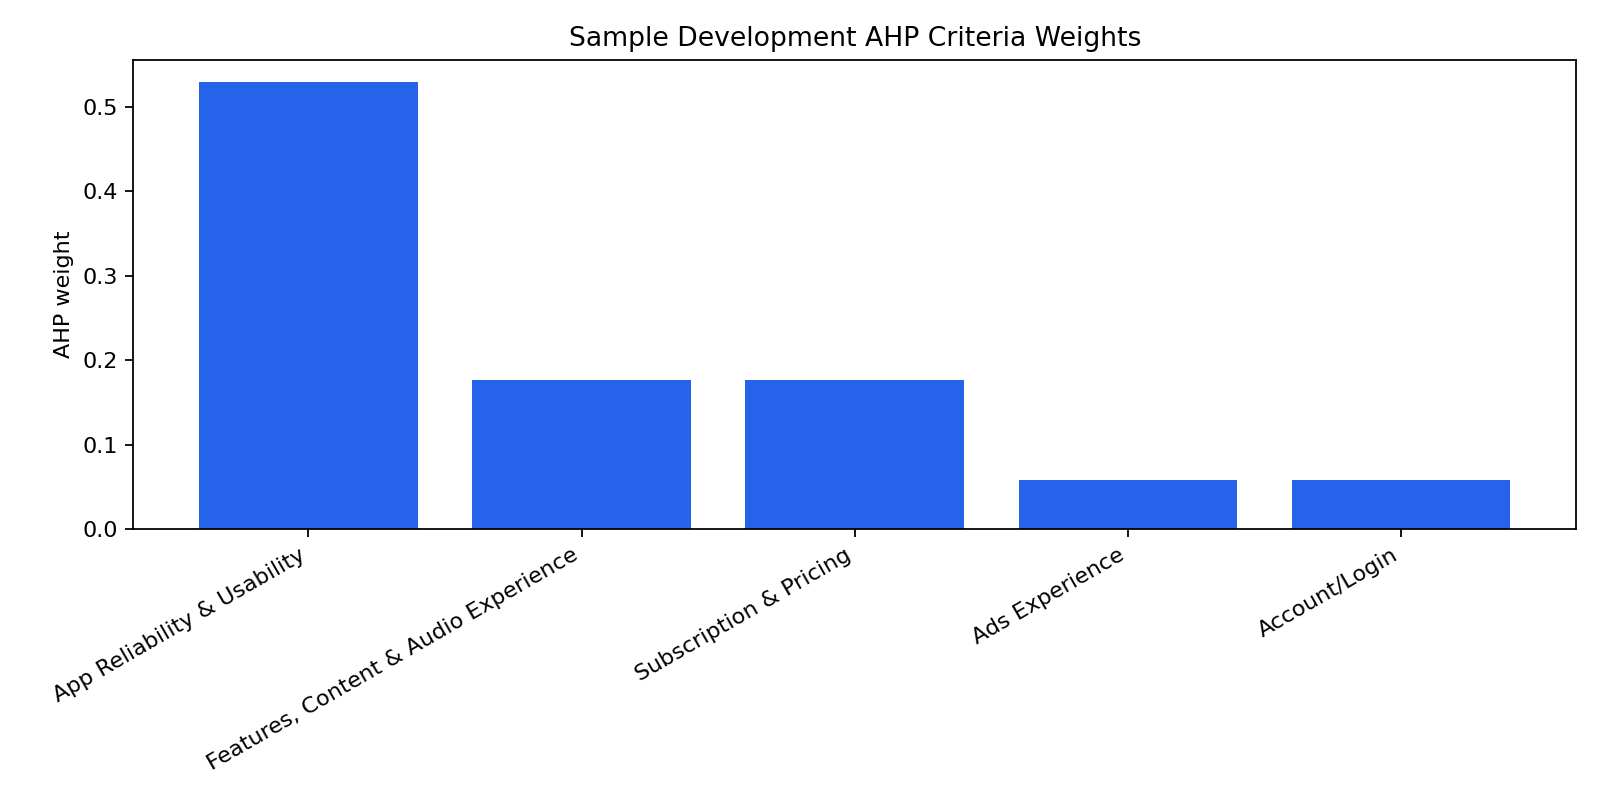

In [7]:
display_image(AHP_FIGURE_DIR / "ahp_weights_sample_development.png")

## Interpretation Notes

- The expected sample CR is approximately `0` because the development matrix was constructed to be internally consistent.
- Real expert responses must still be checked against the `CR <= 0.10` threshold.
- Final AHP weights and priority rankings are intentionally not generated in Phase 10C.

## Phase 10D: Expert Judgement Validation and Aggregation

Before final AHP calculation, real expert judgement files must be validated and aggregated. The cells below use the sample-development input by default, so the generated reports are workflow checks only and are not final expert judgement.

In [8]:
run_ml_script("validate_ahp_expert_judgement.py")
run_ml_script("aggregate_ahp_expert_judgement.py")

AHP validation report JSON: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\06_ahp\validation\ahp_expert_judgement_validation_report.json
AHP validation report CSV: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\06_ahp\validation\ahp_expert_judgement_validation_report.csv
Can calculate: True
Valid respondents: 1
Invalid respondents: 0

AHP aggregated judgement JSON: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\06_ahp\aggregated\ahp_aggregated_pairwise_judgement.json
AHP aggregated judgement CSV: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\06_ahp\aggregated\ahp_aggregated_pairwise_judgement.csv
Total respondents: 1
Aggregated comparisons: 10



In [9]:
AHP_VALIDATION_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "06_ahp" / "validation"
AHP_AGGREGATED_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "06_ahp" / "aggregated"

validation_report = load_json(AHP_VALIDATION_DIR / "ahp_expert_judgement_validation_report.json")
if validation_report:
    display(pd.DataFrame([{
        "run_label": validation_report["run_label"],
        "is_sample": validation_report["is_sample"],
        "can_calculate": validation_report["can_calculate"],
        "total_rows": validation_report["total_rows"],
        "total_respondents": validation_report["total_respondents"],
        "valid_respondent_count": validation_report["valid_respondent_count"],
        "invalid_respondent_count": validation_report["invalid_respondent_count"],
        "issue_count": validation_report["issue_count"],
    }]))
    if validation_report["issues"]:
        display(pd.DataFrame(validation_report["issues"]))

aggregated_df = load_csv(AHP_AGGREGATED_DIR / "ahp_aggregated_pairwise_judgement.csv")
if aggregated_df is not None:
    display(aggregated_df)

,run_label,is_sample,can_calculate,total_rows,total_respondents,valid_respondent_count,invalid_respondent_count,issue_count
0,sample_development_only,True,True,10,1,1,0,0


,run_label,is_sample,not_final_expert_judgement,comparison_id,criterion_a,criterion_b,ahp_value_a_over_b,respondent_count,aggregation_method
0,sample_development_only,True,True,P01,"Features, Content & Audio Experience",App Reliability & Usability,0.333333,1,geometric_mean
1,sample_development_only,True,True,P02,"Features, Content & Audio Experience",Ads Experience,3.000000,1,geometric_mean
2,sample_development_only,True,True,P03,"Features, Content & Audio Experience",Subscription & Pricing,1.000000,1,geometric_mean
3,sample_development_only,True,True,P04,"Features, Content & Audio Experience",Account/Login,3.000000,1,geometric_mean
4,sample_development_only,True,True,P05,App Reliability & Usability,Ads Experience,9.000000,1,geometric_mean
5,sample_development_only,True,True,P06,App Reliability & Usability,Subscription & Pricing,3.000000,1,geometric_mean
6,sample_development_only,True,True,P07,App Reliability & Usability,Account/Login,9.000000,1,geometric_mean
7,sample_development_only,True,True,P08,Ads Experience,Subscription & Pricing,0.333333,1,geometric_mean
8,sample_development_only,True,True,P09,Ads Experience,Account/Login,1.000000,1,geometric_mean
9,sample_development_only,True,True,P10,Subscription & Pricing,Account/Login,3.000000,1,geometric_mean


### Phase 10D Note

The aggregated AHP pairwise judgement is an intermediate artifact only. It is not an AHP weight file and it is not a final ranking. Final AHP calculation must wait for validated real expert judgement data.